In [12]:
#&&&&&&&&&&&&&&&    Importar librería    &&&&&&&&&&&&&&&
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors 


### Parte 1: Análisis Exploratorio y Visualización (3 puntos)

#### 1.1 Exploración Inicial con Pandas y NumPy (1 punto)
* Carga el dataset y muestra las primeras 10 filas
* Genera estadísticas descriptivas completas de las variables numéricas
* Identifica y maneja valores nulos o inconsistentes
* Calcula la correlación entre variables numéricas usando NumPy
* Identifica outliers en horas_estudio_semanal y monto_inversion

In [2]:
#&&&&&&&&&&&&&&&    Reproducibidad   &&&&&&&&&&&&&&&    
random_state = 42
np.random.seed(random_state)

In [43]:
#&&&&&&&&&&&&&&&    Cargar datos   &&&&&&&&&&&&&&&  
df=pd.read_csv(r"c:\Users\Jocelyn Matus Ancavi\Desktop\2026\3.-Curso ciencia de datos\tareas\Tarea mod12 Pfinal\02. Material de apoyo - Estudiantes_edutech.csv")  
pd.set_option('display.max_columns',None) # mostrar todas las columnas
# para ver la forma de los datos 
df.head(10)

,id_estudiante,nombre,edad,genero,pais,horas_estudio_semanal,sesiones_totales,tareas_completadas,tareas_totales,participacion_foros,promedio_evaluaciones,dispositivo_principal,horario_estudio,nivel_educacion,experiencia_previa,monto_inversion,plataforma_origen,curso_completado,puntaje_satisfaccion
0,1,Estudiante_1,56,Otro,Argentina,16,10,31,50,57,64.25,Mobile,Noche,Posgrado,Sí,879,Google,0,4.4
1,2,Estudiante_2,46,Femenino,Colombia,24,76,28,50,20,59.26,Tablet,Noche,Pregrado,No,1959,Google,0,3.4
2,3,Estudiante_3,32,Masculino,Colombia,19,94,42,50,81,84.99,Tablet,Tarde,Pregrado,No,2631,Google,1,9.6
3,4,Estudiante_4,60,Otro,México,8,105,1,50,68,64.76,Desktop,Tarde,Posgrado,No,741,Google,0,4.9
4,5,Estudiante_5,25,Femenino,Colombia,31,1,22,50,2,78.77,Tablet,Tarde,Pregrado,No,4069,Directo,0,4.8
5,6,Estudiante_6,38,Otro,Perú,21,133,18,50,86,78.79,Tablet,Mañana,Pregrado,Sí,981,Facebook,0,5.5
6,7,Estudiante_7,56,Masculino,Perú,17,20,30,50,89,93.28,Mobile,Mañana,Secundaria,No,4986,Facebook,0,8.3
7,8,Estudiante_8,36,Masculino,Chile,23,8,50,50,36,75.92,Mobile,Tarde,Posgrado,Sí,3456,Referido,1,7.2
8,9,Estudiante_9,40,Masculino,Perú,37,171,4,50,87,70.13,Desktop,Tarde,Posgrado,Sí,197,Facebook,0,6.0
9,10,Estudiante_10,28,Otro,Perú,16,1,18,50,48,48.33,Mobile,Mañana,Posgrado,No,1082,Facebook,0,4.0


In [42]:
#&&&&&&&&&&&&&&&    Exploración de datos    &&&&&&&&&&&&&&&
df. info()
print(f'\nFilas:{df.shape[0]}| Columnas:{list(df.columns)}')
print("\nTipos de datos:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_estudiante          500 non-null    int64  
 1   nombre                 500 non-null    object 
 2   edad                   500 non-null    int64  
 3   genero                 500 non-null    object 
 4   pais                   500 non-null    object 
 5   horas_estudio_semanal  500 non-null    int64  
 6   sesiones_totales       500 non-null    int64  
 7   tareas_completadas     500 non-null    int64  
 8   tareas_totales         500 non-null    int64  
 9   participacion_foros    500 non-null    int64  
 10  promedio_evaluaciones  500 non-null    float64
 11  dispositivo_principal  500 non-null    object 
 12  horario_estudio        500 non-null    object 
 13  nivel_educacion        500 non-null    object 
 14  experiencia_previa     500 non-null    object 
 15  monto_

In [5]:
print("\nEstadísticas descriptivas de las variables numericas ")
#df.describe().T

num_col_sin_id = [c for c in df.select_dtypes(include=[np.number]).columns if c !='id_estudiante']
df[num_col_sin_id].describe().T


Estadísticas descriptivas de las variables numericas 


,count,mean,std,min,25%,50%,75%,max
edad,500.0,41.98000,13.800598,18.00,31.00,43.00,53.0000,65.00
horas_estudio_semanal,500.0,20.90200,11.312486,1.00,12.00,20.50,31.0000,40.00
sesiones_totales,500.0,99.65800,58.079527,1.00,48.00,102.00,149.2500,200.00
tareas_completadas,500.0,25.26400,14.359202,0.00,14.00,24.50,38.0000,50.00
tareas_totales,500.0,50.00000,0.000000,50.00,50.00,50.00,50.0000,50.00
participacion_foros,500.0,49.77800,28.892807,0.00,25.00,48.00,75.0000,100.00
promedio_evaluaciones,500.0,71.15994,17.358748,40.03,56.03,72.14,85.7725,99.98
monto_inversion,500.0,2508.95600,1467.201453,61.00,1213.25,2413.50,3876.2500,4992.00
curso_completado,500.0,0.14600,0.353460,0.00,0.00,0.00,0.0000,1.00
puntaje_satisfaccion,500.0,5.35980,1.728496,1.00,4.20,5.30,6.5000,10.00


In [41]:
# Verificación de valores nulos y duplicados 
print("Valores nulos por columna:\n",df.isnull().sum())
##print("\nFilas duplicadas:", df.duplicated().sum())
print("Duplicados por id estudiante:",df['id_estudiante'].duplicated().sum())

Valores nulos por columna:
 id_estudiante            0
nombre                   0
edad                     0
genero                   0
pais                     0
horas_estudio_semanal    0
sesiones_totales         0
tareas_completadas       0
tareas_totales           0
participacion_foros      0
promedio_evaluaciones    0
dispositivo_principal    0
horario_estudio          0
nivel_educacion          0
experiencia_previa       0
monto_inversion          0
plataforma_origen        0
curso_completado         0
puntaje_satisfaccion     0
dtype: int64
Duplicados por id estudiante: 0


In [40]:
# valores fueras de rango 
print("\nRevisión variables dentro del rango:")
print("Filas con tareas completadas > tareas_totales:",(df['tareas_completadas']>df['tareas_totales']).sum())
print("Edades fuera de rango 18-100:",((df['edad']<18)|(df['edad']>100)).sum())
print("puntaje satisfacción fuera de 0-10:",((df['puntaje_satisfaccion']<0)|(df['puntaje_satisfaccion']>10)).sum())


Revisión variables dentro del rango:
Filas con tareas completadas > tareas_totales: 0
Edades fuera de rango 18-100: 0
puntaje satisfacción fuera de 0-10: 0


Dataset no tiene valores nulos, ni duplicados.
a modo de ejemplo muestro a continuación código de depuración como buena práctica.
* df = df.dropna()      # elimina filas con nulos si existieran
* df = df.drop_duplicates(subset='id_estudiante') # elimina duplicados de estudiantes

In [ ]:
#&&&&&&&&&&&&&&&    Identificación de variable       &&&&&&&&&&&&&&& 
# en este caso tenemos variable tipo int,str,obj y float 
# por lo que no errado usar include number  y object
print('\n=== Variables cuantitativas y categóricas ===')
print('Cuantitativas:', df.select_dtypes(include='number').columns.tolist())
print('Categóricas:  ', df.select_dtypes(include='object').columns.tolist())


=== Variables cuantitativas y categóricas ===
Cuantitativas: ['id_estudiante', 'edad', 'horas_estudio_semanal', 'sesiones_totales', 'tareas_completadas', 'tareas_totales', 'participacion_foros', 'promedio_evaluaciones', 'monto_inversion', 'curso_completado', 'puntaje_satisfaccion']
Categóricas:   ['nombre', 'genero', 'pais', 'dispositivo_principal', 'horario_estudio', 'nivel_educacion', 'experiencia_previa', 'plataforma_origen']


> **Buena práctica: diccionario de etiquetas para visualización**

Como se van hacer gráficos de sns y plt es bueno hacer un diccionario de etiqueta para que en los label de las variables queden sin "_" y en términos de costo computacional tambien se recomienda y toma mayor peso cuando los data set son mas grandes, Además así tampoco se modifica el dataframe original.

In [33]:
# Etiquetas legibles 
Etiquetas = {
    "id_estudiante": "ID Estudiante",
    "nombre": "Nombre",
    "edad": "Edad",
    "genero": "Género",
    "pais": "País",
    "horas_estudio_semanal": "Horas de Estudio Semanal",
    "sesiones_totales": "Sesiones Totales",
    "tareas_completadas": "Tareas Completadas",
    "tareas_totales": "Tareas Totales",
    "participacion_foros": "Participación en Foros",
    "promedio_evaluaciones": "Promedio de Evaluaciones",
    "dispositivo_principal": "Dispositivo Principal",
    "horario_estudio": "Horario de Estudio",
    "nivel_educacion": "Nivel de Educación",
    "experiencia_previa": "Experiencia Previa",
    "monto_inversion": "Monto de Inversión",
    "plataforma_origen": "Plataforma de Origen",
    "curso_completado": "Curso Completado",
    "puntaje_satisfaccion": "Puntaje de Satisfacción",
}
df_plot = df.rename(columns=Etiquetas)

Antes de calcula correlación, es necesario revisar como distribuyen las variables entre otras cosas, para saber si se debe aplicar Pearson (y hacer inferencia sobre él)  o Spearman, ya que Pearson asume:
 *variables cuantitativas continuas
 *relación lineal
 * normalidad de ambas variables
 *  observaciones independientes
 si esto no se cumple lo adecuado es usar Spearman.
dejo referencia, página 9: https://revistes.ub.edu/index.php/REIRE/article/view/reire2019.12.228245/29310

>**Buena práctica hacer una grilla dinámica**
Se consigue que se ajuste al n° real de variables  

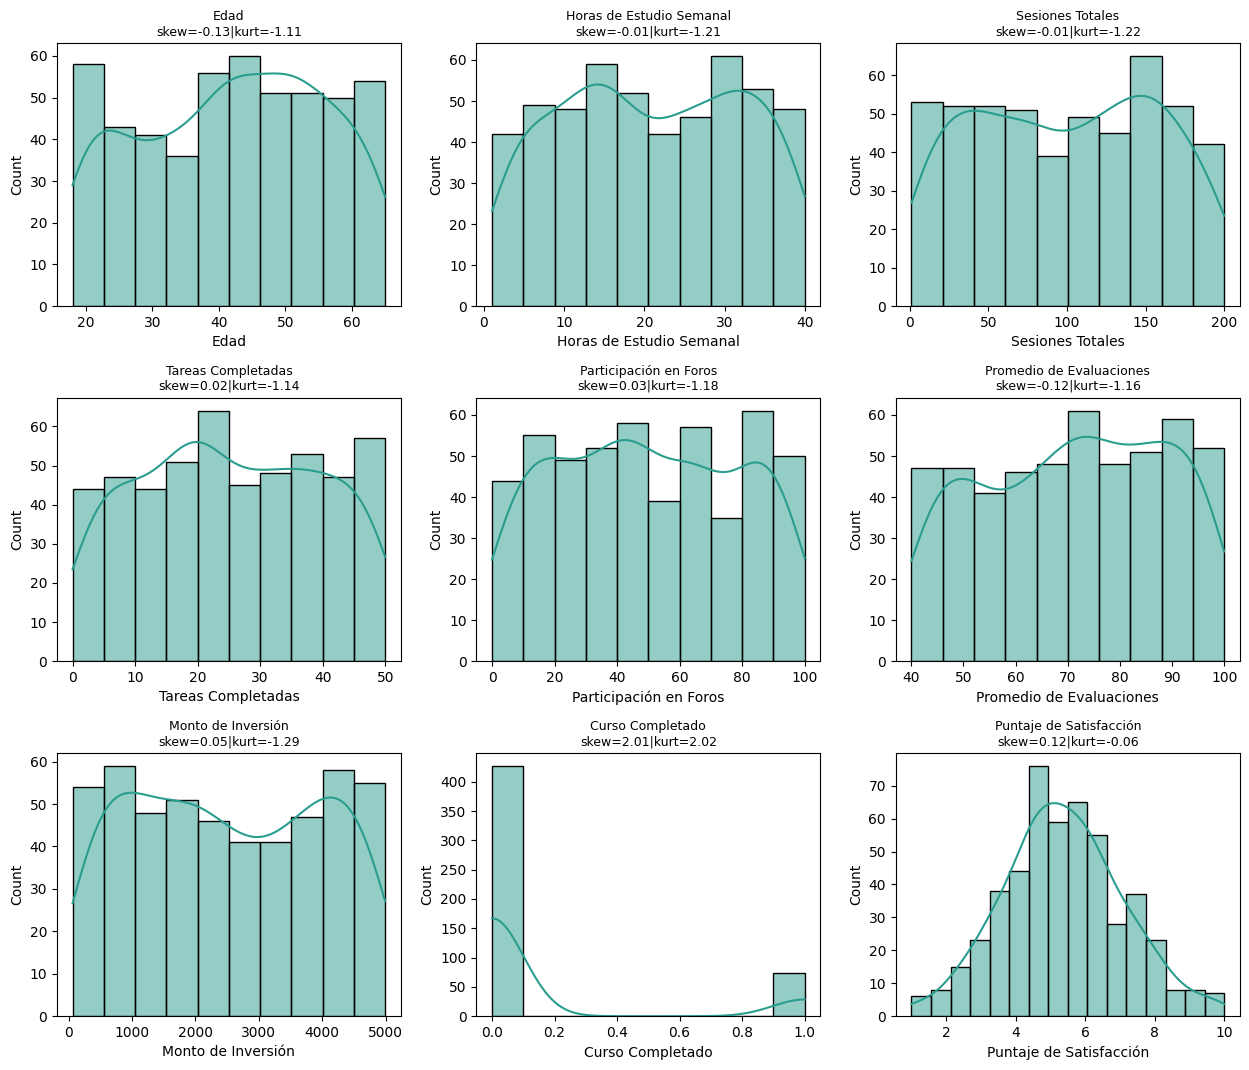

In [45]:
# Distribución de cada variable numérica: 
# histograma + asimetría (skew) + curtosis
col_dist = [c for c in num_col_sin_id if df[c].std() > 0]

# Grilla dinámica
ncol = 3
nrows = -(-len(col_dist) // ncol)  # techo de la división
fig, axes = plt.subplots(nrows, ncol, figsize=(4.2*ncol,3.6*nrows))
axes = axes.flatten()
# fin grilla dinámica

for ax, col in zip(axes, col_dist):
    sns.histplot(df[col], kde=True, ax=ax, color='#2A9D8F')
    skew = stats.skew(df[col])
    kurt = stats.kurtosis(df[col])
    ax.set_title(f'{Etiquetas.get(col,col)}\nskew={skew:.2f}|kurt={kurt:.2f}',fontsize=9)
    ax.set_xlabel(Etiquetas.get(col,col))

for ax in axes[len(col_dist):]:  # oculta ejes sobrantes de la grilla, si los hay
    ax.axis('off')

plt.tight_layout()
plt.show()

Casi todas las variables tiene skewness cercano a 0, lo que significa que hay simetría pero curtosis es negativa, por lo que estamos antes una distribución uniforme, mas que ser una distribución normal. exceptuando a la variable puntaje satisfacción que tiene una curtorsi cerca a -0.06 si es compatible con uan distribución normal y claramente esto se ve en el subplot posicion a33 (inferior derecha)

In [46]:
# Test de normalidad Shapiro-Wilk (H0: la variable se distribuye normal)
print("Test de normalidad (Shapiro-Wilk):")
for col in col_dist:
    stat,p = stats.shapiro(df[col])
    veredicto = "NO normal" if p<0.05 else"normal"
    print(f" {col:<25} p={p:.4f} ->{veredicto}")

Test de normalidad (Shapiro-Wilk):
 edad                      p=0.0000 ->NO normal
 horas_estudio_semanal     p=0.0000 ->NO normal
 sesiones_totales          p=0.0000 ->NO normal
 tareas_completadas        p=0.0000 ->NO normal
 participacion_foros       p=0.0000 ->NO normal
 promedio_evaluaciones     p=0.0000 ->NO normal
 monto_inversion           p=0.0000 ->NO normal
 curso_completado          p=0.0000 ->NO normal
 puntaje_satisfaccion      p=0.2504 ->normal


El test de Shapiro-Wilk muestra que la mayoría de las variables de este dataset no cumplen el supuesto de normalidad (p < 0.05), por lo que, siguiendo esta referencia, no se reportarán intervalos de confianza ni valores-p para los coeficientes individuales de Pearson. 

de todo el analisis anterior, gráficos de distribución y test de Shapiro-Wilk es que concluyo que es mas apropiado usar correlacion de spearman aun así se deja el codigo de calculo de correlacion de Pearson

In [47]:
# Correlación entre variables numéricas usando NumPy
#se calcula la correlacion de pearson solo con la finalidad de mostrar el código
# Se excluye 'tareas_totales' por tener varianza cero (desviación estándar = 0)
col_corr = [c for c in num_col_sin_id if df[c].std() > 0]
corr_matrix = np.corrcoef(df[col_corr].values,rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=col_corr,columns=col_corr)
corr_df.round(2)

,edad,horas_estudio_semanal,sesiones_totales,tareas_completadas,participacion_foros,promedio_evaluaciones,monto_inversion,curso_completado,puntaje_satisfaccion
edad,1.00,-0.05,0.04,-0.06,-0.04,0.03,-0.11,-0.07,-0.03
horas_estudio_semanal,-0.05,1.00,0.00,0.01,0.02,-0.04,0.04,0.13,0.04
sesiones_totales,0.04,0.00,1.00,-0.03,-0.07,-0.03,0.00,-0.06,-0.05
tareas_completadas,-0.06,0.01,-0.03,1.00,-0.02,-0.06,0.03,0.52,0.16
participacion_foros,-0.04,0.02,-0.07,-0.02,1.00,-0.02,-0.03,-0.06,0.50
promedio_evaluaciones,0.03,-0.04,-0.03,-0.06,-0.02,1.00,0.03,0.21,0.53
monto_inversion,-0.11,0.04,0.00,0.03,-0.03,0.03,1.00,0.06,0.05
curso_completado,-0.07,0.13,-0.06,0.52,-0.06,0.21,0.06,1.00,0.45
puntaje_satisfaccion,-0.03,0.04,-0.05,0.16,0.50,0.53,0.05,0.45,1.00


In [48]:
# Correlación de Spearman 
corr_spearman = df[col_corr].corr(method='spearman')
diff = (corr_df - corr_spearman).abs()
print("Diferencia absoluta máxima entre Pearson y Spearman:", diff.values.max().round(3))
corr_spearman.round(2)

Diferencia absoluta máxima entre Pearson y Spearman: 0.029


,edad,horas_estudio_semanal,sesiones_totales,tareas_completadas,participacion_foros,promedio_evaluaciones,monto_inversion,curso_completado,puntaje_satisfaccion
edad,1.00,-0.05,0.03,-0.06,-0.04,0.03,-0.10,-0.07,-0.02
horas_estudio_semanal,-0.05,1.00,0.00,0.01,0.02,-0.05,0.04,0.13,0.03
sesiones_totales,0.03,0.00,1.00,-0.03,-0.07,-0.03,-0.00,-0.06,-0.05
tareas_completadas,-0.06,0.01,-0.03,1.00,-0.02,-0.06,0.03,0.52,0.15
participacion_foros,-0.04,0.02,-0.07,-0.02,1.00,-0.02,-0.03,-0.06,0.48
promedio_evaluaciones,0.03,-0.05,-0.03,-0.06,-0.02,1.00,0.03,0.20,0.54
monto_inversion,-0.10,0.04,-0.00,0.03,-0.03,0.03,1.00,0.07,0.04
curso_completado,-0.07,0.13,-0.06,0.52,-0.06,0.20,0.07,1.00,0.42
puntaje_satisfaccion,-0.02,0.03,-0.05,0.15,0.48,0.54,0.04,0.42,1.00


La variables:
* tareas completadas correlaciona fuertemente con curso_completado (0.52)
* participación foros (0.50) y promedio evaluaciones (0.53) correlacionan con puntaje_satisfaccion. 
Estas variables serán más relevantes para los modelos predictivos de las Partes 3 y 4. 

Al comparar con Spearman, la diferencia máxima entre ambos métodos es de apenas ~0.03, lo que confirma que, pese a la no-normalidad detectada, Pearson no está distorsionando las conclusiones en este caso particular.


Revisión variables dentro del rango:
Filas con tareas completadas > tareas_totales: 0
Edades fuera de rango 18-100: 0
puntaje satisfacción fuera de 0-10: 0


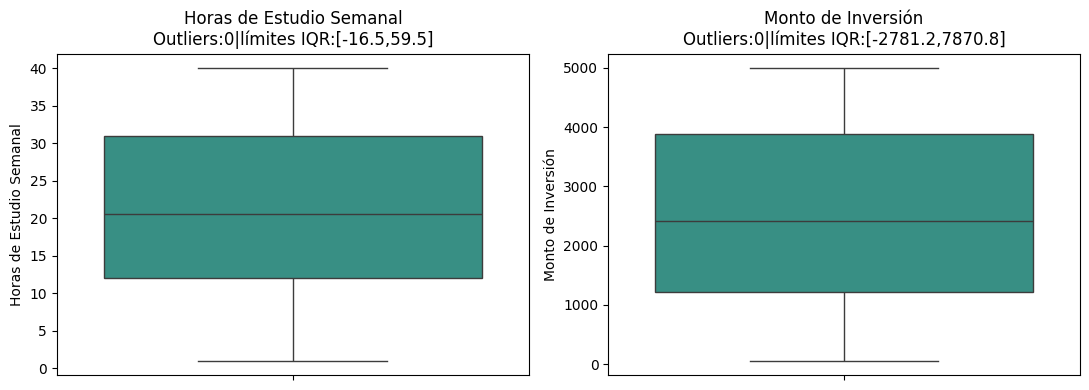

In [49]:
#&&&&&&&&&&&&&&&    Detección de outliers   &&&&&&&&&&&&&&&
# valores fueras de rango 
print("\nRevisión variables dentro del rango:")
print("Filas con tareas completadas > tareas_totales:",(df['tareas_completadas']>df['tareas_totales']).sum())
print("Edades fuera de rango 18-100:",((df['edad']<18)|(df['edad']>100)).sum())
print("puntaje satisfacción fuera de 0-10:",((df['puntaje_satisfaccion']<0)|(df['puntaje_satisfaccion']>10)).sum())
# Identificación de outliers con método IQR 
# para horas estudio semanal y monto inversión
def detectar_outliers_iqr(serie):
    q1,q3 = np.percentile(serie,[25,75])
    iqr = q3-q1
    lim_inf, lim_sup = q1-1.5*iqr,q3+1.5*iqr
    outliers = serie[(serie<lim_inf)|(serie>lim_sup)]
    return outliers,lim_inf,lim_sup

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes,['horas_estudio_semanal','monto_inversion']):
    outliers, li,ls=detectar_outliers_iqr(df[col])
    sns.boxplot(y=df[col],ax=ax,color='#2A9D8F')
    ax.set_title(f'{Etiquetas.get(col,col)}\nOutliers:{len(outliers)}|límites IQR:[{li:.1f},{ls:.1f}]')
    ax.set_ylabel(Etiquetas.get(col,col))
plt.tight_layout()
plt.show()


Con respecto a los outliers:
* horas estudio semanal está en el rango de 1-40
* monto inversion está en el rango 61-4.992
Ambos muestran que **no** están fuera de los límites de Tukey.(Q1 − 1.5·IQR, Q3 + 1.5·IQR).
Igual de los boxplot se ve que no hay valores fuera de los bigotes 

#### 1.2 Visualización Avanzada con Seaborn (1 punto)
* Crea un pairplot que muestre las relaciones entre horas_estudio_semanal, participacion_foros, promedio_evaluaciones y puntaje_satisfaccion, diferenciando por curso_completado
* Genera un heatmap de la matriz de correlación de todas las variables numéricas
* Construye un violinplot comparando la distribución de puntaje_satisfaccion por nivel_educacion

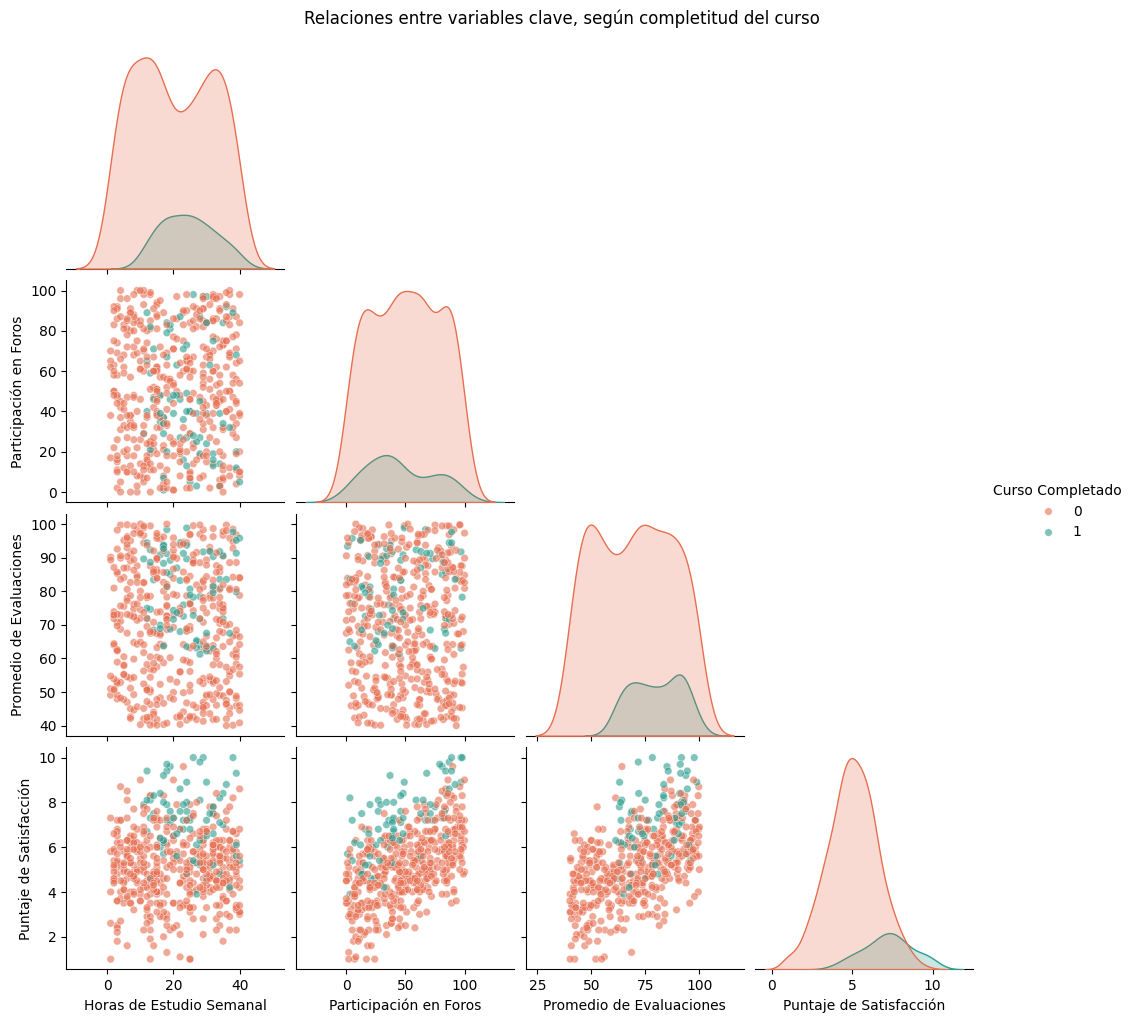

In [ ]:
#&&&&&&&&&&&&&&&    Pairplot   &&&&&&&&&&&&&&&
#relaciones entre variables seleccionadas, diferenciando por curso_completado
g = sns.pairplot(
    df_plot,
    vars=[Etiquetas['horas_estudio_semanal'],Etiquetas['participacion_foros'],
          Etiquetas['promedio_evaluaciones'],Etiquetas['puntaje_satisfaccion']],
    hue=Etiquetas['curso_completado'],
    palette={0:'#E76F51',1:'#2A9D8F'},
    diag_kind='kde',
    corner=True,                    # evita duplicar los gráficos espejo (arriba/abajo de la diagonal)
    plot_kws={'alpha':0.6,'s':30})
g.fig.suptitle('Relaciones entre variables clave, según completitud del curso', y=1.02)
plt.show()

Interpretación del pairplot,  se puede ver que los estudiantes que completan el curso (verde) tienden a tener mayor participacion_foros y promedio evaluaciones, y muestran una distribución de puntaje satisfaccion desplazada hacia valores más altos. 

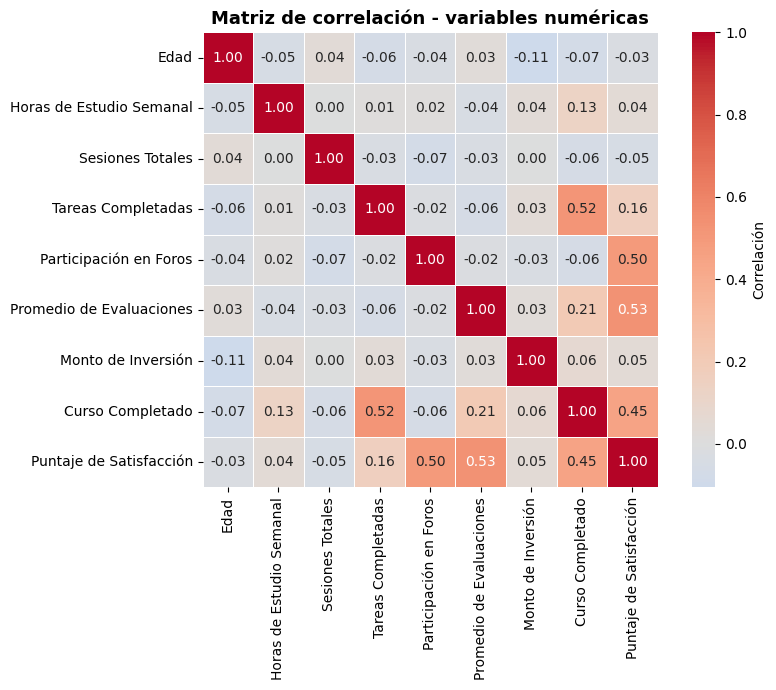

In [ ]:
#&&&&&&&&&&&&&&&    Heatmap   &&&&&&&&&&&&&&&
plt.figure(figsize=(9, 7))
corr = df[col_corr].corr().rename(index=Etiquetas, columns=Etiquetas)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
square=True, linewidths=0.5, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlación - variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&